![Machine Learning Lab](banner.jpg)


# Laboratorio 5 Actividad


## Instrucciones generales


1. Esta actividad debe ser entregada por BN y es de carácter individual. No se permite entregar el laboratorio después de la fecha establecida.
2. Al responder las preguntas de las actividades por favor marcar las respuestas con la sección a la que corresponden, por ejemplo: `## Exploración de datos 2.1`. Es preferible que esto lo hagan con secciones de MarkDown.
3. Por favor nombrar el archivo de acuerdo al siguiente formato `{email}_lab5.ipynb`.
4. Si tienen alguna duda pueden escribirme a mi correo `j.rayom@uniandes.edu.co` o contactarme directamente por Teams

### 0\. Descarga del dataset

Utiliza el siguiente enlace para descargar el dataset de Twitter Tweets Sentiment:

[Descargar Dataset](https://www.kaggle.com/datasets/yasserh/twitter-tweets-sentiment-dataset)

El dataset contiene tweets reales con clasificación de sentimiento en 3 clases (positive/negative/neutral)


### 1\. Exploración de datos (5%)

1. **Carga del dataset**:
   - Cargar el dataset
   - Seleccionar solo las columnas necesarias: `text` y `sentiment`
   - Eliminar filas con valores faltantes

2. **Análisis exploratorio**:
   - Analizar las primeras 10 filas del dataset limpio
   - Mostrar la distribución de clases (Positive, Negative, Neutral)
   - Verificar el tamaño final del dataset


### 2\. Procesamiento de datos (15%)

Los algoritmos de Machine Learninng no trabajan directamente con texto. Por eso debemos convertir palabras en vectores numéricos mediante técnicas como [Bag-of-Words](https://www.ibm.com/think/topics/bag-of-words), un método que cuantifica la frecuencia de palabras en documentos de texto. Esto transforma frases como "muy muy mala pelicula" en vectores como [0, 2, 1, 1, 0, 0, ..., 0] donde cada posición representa una palabra del vocabulario.

Scikit-learn provee una clase [`CountVectorizer`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) que convierte una colección de documentos a una matriz de conteo de palabras. Adicionalmente, realiza procesamiento convirtiendo el texto a minúsculas y eliminando palabras que no aportan valor a la predicción.

1. Divide el dataset en 80/20 con `train_test_split()`, `stratify=sentiment`, y `random_state=42`.
2. Usa CountVectorizer usando `lowercase=True` y `stop_words='english'` e inicializalo con el conjunto de entrenamiento usando `fit_transform`
   
   ```python
   from sklearn.feature_extraction.text import CountVectorizer
   
   # Vectorizador automático
   vectorizer = CountVectorizer(lowercase=True, stop_words='english')
   
   ...
   ```
3. Compara 3 textos originales con el texto procesado por `CountVectorizer`.

### 3\. Entrenamiento de Naïve Bayes (60%)

1. **Entrenamiento de modelos**:
   - Entrena un modelo de [MultinomialNB](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html) (para frecuencias de palabras)
   - Entrena un modelo de [BernoulliNB](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.BernoulliNB.html) (para presencia/ausencia de palabras)

2. **Evaluación y métricas**:
   - Reporta **accuracy**, **precision**, **recall**, y **F1-score** de cada modelo

3. **Análisis comparativo**:
   - ¿Qué modelo obtuvo el mejor rendimiento?

### 4\. Predicciones (20%)

1. Realiza 3 predicciones con el mejor modelo sobre nuevos tweets que demuestren como clasifica el modelo el texto para cada una de las clases.

---

### 1\. Exploración de datos (5%)

1. **Carga del dataset**:
   - Cargar el dataset
   - Seleccionar solo las columnas necesarias: `text` y `sentiment`
   - Eliminar filas con valores faltantes

2. **Análisis exploratorio**:
   - Analizar las primeras 10 filas del dataset limpio
   - Mostrar la distribución de clases (Positive, Negative, Neutral)
   - Verificar el tamaño final del dataset

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [5]:
# 1. Cargar el dataset, seleccionar solo text y sentiment y eliminar filas con valores faltantes
tweets_df = pd.read_csv('datasets/Tweets.csv')[['text', 'sentiment']].dropna()

# 2.1 Obtener las primeras 10 filas del dataset limpip
filas_10 =tweets_df.head(10).to_dict(orient='records')
filas_10

[{'text': ' I`d have responded, if I were going', 'sentiment': 'neutral'},
 {'text': ' Sooo SAD I will miss you here in San Diego!!!',
  'sentiment': 'negative'},
 {'text': 'my boss is bullying me...', 'sentiment': 'negative'},
 {'text': ' what interview! leave me alone', 'sentiment': 'negative'},
 {'text': ' Sons of ****, why couldn`t they put them on the releases we already bought',
  'sentiment': 'negative'},
 {'text': 'http://www.dothebouncy.com/smf - some shameless plugging for the best Rangers forum on earth',
  'sentiment': 'neutral'},
 {'text': '2am feedings for the baby are fun when he is all smiles and coos',
  'sentiment': 'positive'},
 {'text': 'Soooo high', 'sentiment': 'neutral'},
 {'text': ' Both of you', 'sentiment': 'neutral'},
 {'text': ' Journey!? Wow... u just became cooler.  hehe... (is that possible!?)',
  'sentiment': 'positive'}]

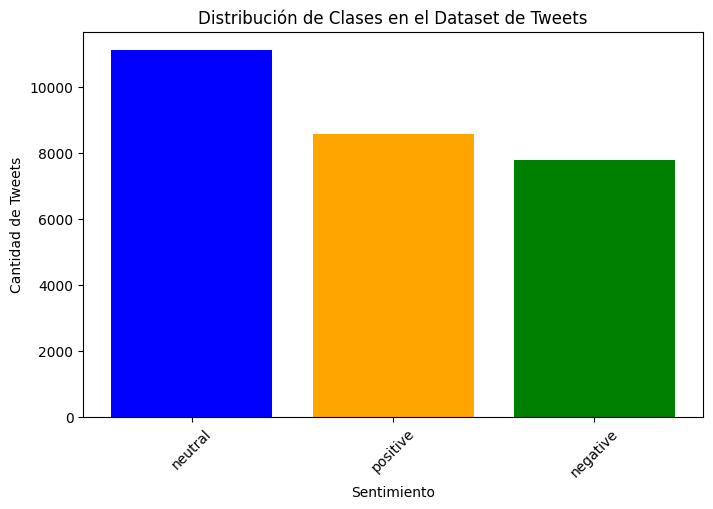

In [7]:
# 2.2 distribución de clases en un barplot
distribucion_clases = tweets_df['sentiment'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(distribucion_clases.index, distribucion_clases.values, color=['blue', 'orange', 'green'])
plt.title('Distribución de Clases en el Dataset de Tweets')
plt.xlabel('Sentimiento')
plt.ylabel('Cantidad de Tweets')
plt.xticks(rotation=45)
plt.show()

Las clases están medianamente balanceadas, con una ligera predominancia de tweets neutrales.

In [9]:
#2.3 mostrar el tamaño final del dataset limpio
print(f"Tamaño del dataset limpio: {tweets_df.shape[0]} filas")

Tamaño del dataset limpio: 27480 filas


### 2\. Procesamiento de datos (15%)

Los algoritmos de Machine Learninng no trabajan directamente con texto. Por eso debemos convertir palabras en vectores numéricos mediante técnicas como [Bag-of-Words](https://www.ibm.com/think/topics/bag-of-words), un método que cuantifica la frecuencia de palabras en documentos de texto. Esto transforma frases como "muy muy mala pelicula" en vectores como [0, 2, 1, 1, 0, 0, ..., 0] donde cada posición representa una palabra del vocabulario.

Scikit-learn provee una clase [`CountVectorizer`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) que convierte una colección de documentos a una matriz de conteo de palabras. Adicionalmente, realiza procesamiento convirtiendo el texto a minúsculas y eliminando palabras que no aportan valor a la predicción.

1. Divide el dataset en 80/20 con `train_test_split()`, `stratify=sentiment`, y `random_state=42`.
2. Usa CountVectorizer usando `lowercase=True` y `stop_words='english'` e inicializalo con el conjunto de entrenamiento usando `fit_transform`
   
   ```python
   from sklearn.feature_extraction.text import CountVectorizer
   
   # Vectorizador automático
   vectorizer = CountVectorizer(lowercase=True, stop_words='english')
   
   ...
   ```
3. Compara 3 textos originales con el texto procesado por `CountVectorizer`.

In [19]:
#1. dividir el dataset en 80 entrenamiento 20 test
X = tweets_df['text']
y = tweets_df['sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#2. usar count vectorizer para vectorizar el texto
vectorizer = CountVectorizer(lowercase=True, stop_words='english') # Eliminar stop words y convertir a minúsculas
X_train_vectorized = vectorizer.fit_transform(X_train) # ajustar el vectorizador a train
X_test_vectorized = vectorizer.transform(X_test) # aplicar el mismo vectorizador a test (sirve luego)

#3. Comparar tres textos originales con su texto procesado
preprocesor = vectorizer.build_analyzer() # obtener el analizador del vectorizador para procesar los textos originales
textos_originales = X_train.head(3).tolist()
textos_procesados = [preprocesor(texto) for texto in textos_originales]

for i in range(3):
    print(f"Texto Original {i+1}: {textos_originales[i]}")
    print(f"Texto Procesado {i+1}: {' '.join(textos_procesados[i])}")
    print("-" * 50)

Texto Original 1:  Press `Ctrl` on bottom right. It`s there.  KY
Texto Procesado 1: press ctrl right ky
--------------------------------------------------
Texto Original 2: ah remember the days when you`d sleep in until noon? well guess who did that today? god i feel like a loser
Texto Procesado 2: ah remember days sleep noon guess did today god feel like loser
--------------------------------------------------
Texto Original 3: my momma is comin 2night !  2morrow tennis day with p?nar yuppie !
Texto Procesado 3: momma comin 2night 2morrow tennis day nar yuppie
--------------------------------------------------


Para comparar el texto original con el procesamiento que se le da en CountVectorizer, utilizamos el método de build_analyzer(), que retorna una lista con el texto en minúsculas, sin stopwords y tokenizado. Observamos una limpieza extra que se le da al eliminar caracteres especiales y puntuación.

### 3\. Entrenamiento de Naïve Bayes (60%)

1. **Entrenamiento de modelos**:
   - Entrena un modelo de [MultinomialNB](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html) (para frecuencias de palabras)
   - Entrena un modelo de [BernoulliNB](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.BernoulliNB.html) (para presencia/ausencia de palabras)

2. **Evaluación y métricas**:
   - Reporta **accuracy**, **precision**, **recall**, y **F1-score** de cada modelo

3. **Análisis comparativo**:
   - ¿Qué modelo obtuvo el mejor rendimiento?

In [ ]:
# definimos una función para entrenamiento y evaluación de modelos
def entrenar_evaluar_modelo(modelo, X_train_vec, y_train, X_test_vec, y_test):
    # entrenar el modelo
    modelo.fit(X_train_vec, y_train)
    # predecir en test
    y_pred = modelo.predict(X_test_vec)

    # obtener accuracy, precision, recall y f1-score
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"Resultados para {modelo.__class__.__name__}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    # obtener reporte de clasificación
    reporte = classification_report(y_test, y_pred)
    print(reporte)

    # obtener matriz de confusión
    cm = confusion_matrix(y_test, y_pred)

    # graficar matriz de confusión
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=modelo.classes_, yticklabels=modelo.classes_, cbar=False)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Matriz de Confusión - {modelo.__class__.__name__}')
    plt.show()

**Modelo MultinomialNB**

Resultados para MultinomialNB:
Accuracy: 0.6437
Precision: 0.6494
Recall: 0.6437
F1-Score: 0.6444
              precision    recall  f1-score   support

    negative       0.68      0.60      0.64      1556
     neutral       0.59      0.67      0.63      2223
    positive       0.70      0.65      0.68      1717

    accuracy                           0.64      5496
   macro avg       0.66      0.64      0.65      5496
weighted avg       0.65      0.64      0.64      5496



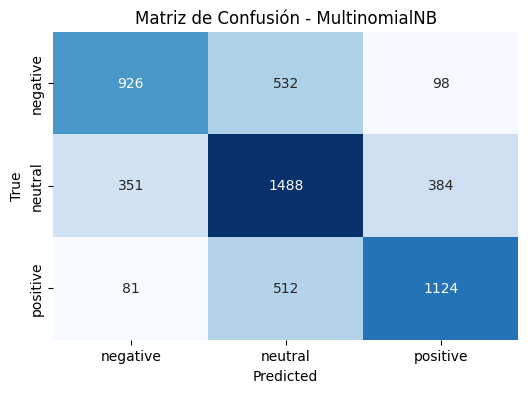

In [34]:
# instanciar el modelo MultinomialNB
model_mnb = MultinomialNB()

# entrenar y evaluar el modelo MultinomialNB
entrenar_evaluar_modelo(model_mnb, X_train_vectorized, y_train, X_test_vectorized, y_test)

**Modelo BernoulliNB**

Resultados para BernoulliNB:
Accuracy: 0.6303
Precision: 0.6737
Recall: 0.6303
F1-Score: 0.6237
              precision    recall  f1-score   support

    negative       0.74      0.43      0.54      1556
     neutral       0.54      0.82      0.66      2223
    positive       0.79      0.57      0.66      1717

    accuracy                           0.63      5496
   macro avg       0.69      0.61      0.62      5496
weighted avg       0.67      0.63      0.62      5496



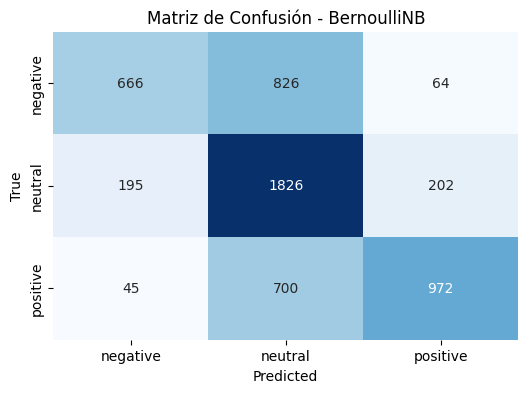

In [35]:
# instanciar el modelo BernoulliNB
model_bnb = BernoulliNB()

# entrenar y evaluar el modelo BernoulliNB
entrenar_evaluar_modelo(model_bnb, X_train_vectorized, y_train, X_test_vectorized, y_test)

Guiados por las métricas de accuracy y F1-score, además de la matriz de confusión, el modelo MultinomialNB obtuvo un mejor rendimiento que el modelo BernoulliNB. Esto se debe a que el modelo MultinomialNB se adapta mejor a datos con frecuencias de palabras, mientras que el modelo BernoulliNB es más adecuado para datos binarios (presencia/ausencia de palabras). En este caso, la naturaleza del dataset y la representación de las características favorecieron al modelo MultinomialNB.

### 4\. Predicciones (20%)

1. Realiza 3 predicciones con el mejor modelo sobre nuevos tweets que demuestren como clasifica el modelo el texto para cada una de las clases.


In [37]:
# creamos 3 tweets nuevos
nuevos_tweets = [
    "I love this product! It's amazing and works perfectly.",
    "This is the worst experience I've ever had. Totally disappointed.",
    "I ate a hamburger for lunch."
]

# vectorizamos los nuevos tweets
nuevos_tweets_vectorizados = vectorizer.transform(nuevos_tweets)

# predecimos con multinomialNB
predicciones_mnb = model_mnb.predict(nuevos_tweets_vectorizados)
print("Predicciones MultinomialNB:")
for tweet, pred in zip(nuevos_tweets, predicciones_mnb):
    print(f"Tweet: '{tweet}' -> Predicción: {pred}")

Predicciones MultinomialNB:
Tweet: 'I love this product! It's amazing and works perfectly.' -> Predicción: positive
Tweet: 'This is the worst experience I've ever had. Totally disappointed.' -> Predicción: negative
Tweet: 'I ate a hamburger for lunch.' -> Predicción: neutral
